In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay
from sklearn.ensemble import RandomForestClassifier


In [2]:
df=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Databel-Churned.csv" , sep=';')

# **Data Description**

In [3]:
print ("shape :" , df.shape)

shape : (6687, 34)


In [4]:
print (df.head())

  Customer ID Churn Label  Account Length (in months)  Local Calls Local Mins  \
0   6145-MBHF          No                          20           40      141,1   
1   0521-NSRI          No                          36           88      179,2   
2   2605-TOXT          No                          47          116      281,8   
3   7023-YWYM          No                          46          145      325,3   
4   0111-ULQC          No                          40          118      242,7   

   Intl Calls Intl Mins Intl Active Intl Plan  Extra International Charges  \
0           0         0          No        no                            0   
1           0         0          No        no                            0   
2           0         0          No        no                            0   
3           0         0          No        no                            0   
4           0         0          No        no                            0   

   ...  Payment Method  Monthly Charge Total

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6687 entries, 0 to 6686
Data columns (total 34 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   Customer ID                        6687 non-null   object
 1   Churn Label                        6687 non-null   object
 2   Account Length (in months)         6687 non-null   int64 
 3   Local Calls                        6687 non-null   int64 
 4   Local Mins                         6687 non-null   object
 5   Intl Calls                         6687 non-null   int64 
 6   Intl Mins                          6687 non-null   object
 7   Intl Active                        6687 non-null   object
 8   Intl Plan                          6687 non-null   object
 9   Extra International Charges        6687 non-null   int64 
 10  Customer Service Calls             6687 non-null   int64 
 11  Avg Monthly GB Download            6687 non-null   int64 
 12  Unlimi

In [6]:
df.describe()

,Account Length (in months),Local Calls,Intl Calls,Extra International Charges,Customer Service Calls,Avg Monthly GB Download,Extra Data Charges,Age,Number of Customers in Group,Total Charges,Churned,Age (bins)
count,6687.000000,6687.000000,6687.000000,6687.000000,6687.000000,6687.000000,6687.000000,6687.000000,6687.000000,6687.000000,6687.000000,6687.000000
mean,32.337820,130.974129,51.097802,33.642889,0.915657,6.696276,3.374458,47.448632,0.837894,1083.755645,0.268581,45.434425
std,24.595689,121.893966,103.592440,76.348332,1.411484,7.454339,12.565309,16.969893,1.700780,1127.074863,0.443254,17.056473
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,19.000000,0.000000,6.000000,0.000000,15.000000
25%,9.000000,31.000000,0.000000,0.000000,0.000000,1.000000,0.000000,33.000000,0.000000,181.000000,0.000000,30.000000
50%,29.000000,98.000000,0.000000,0.000000,0.000000,5.000000,0.000000,47.000000,0.000000,647.000000,0.000000,45.000000
75%,55.000000,199.000000,52.000000,16.000000,2.000000,9.000000,0.000000,60.000000,0.000000,1732.500000,1.000000,60.000000
max,77.000000,918.000000,1120.000000,586.000000,5.000000,43.000000,99.000000,85.000000,6.000000,5574.000000,1.000000,85.000000


# **Data Cleaning**

In [7]:
# Remplacer les , par .
df = df.replace(',', '.', regex=True)

# Convertir en float
cols_to_convert = ['Local Mins', 'Intl Mins']

for col in cols_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [8]:
# Remplacer $ par " "
df['Monthly Charge'] = df['Monthly Charge'].replace('[\$,]', '', regex=True).astype(float)

<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_18139/3121462433.py:2: SyntaxWarning: invalid escape sequence '\$'
  df['Monthly Charge'] = df['Monthly Charge'].replace('[\$,]', '', regex=True).astype(float)


In [9]:
#Supprimer Colonne Unitile
df.drop(['Phone Number'], axis=1, inplace=True)


In [10]:
df.drop(['Customer ID'], axis=1, inplace=True)

In [11]:
df.columns


Index(['Churn Label', 'Account Length (in months)', 'Local Calls',
       'Local Mins', 'Intl Calls', 'Intl Mins', 'Intl Active', 'Intl Plan',
       'Extra International Charges', 'Customer Service Calls',
       'Avg Monthly GB Download', 'Unlimited Data Plan', 'Extra Data Charges',
       'State', 'Gender', 'Age', 'Under 30', 'Senior', 'Group',
       'Number of Customers in Group', 'Device Protection & Online Backup',
       'Contract Type', 'Payment Method', 'Monthly Charge', 'Total Charges',
       'Churn Category', 'Churn Reason', 'Churned', 'Demographics',
       'Age (bins)', 'Contract Category', 'Grouped Consumption'],
      dtype='object')

# **Exploratory Data Analysis EDA**

Churn Rate : 26.86 %


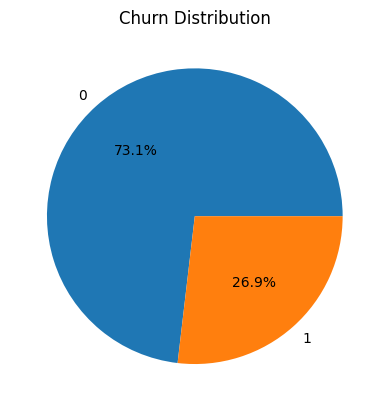

In [15]:
#Taux de Churn Global
churn_rate = df["Churned"].mean()
print("Churn Rate :", round(churn_rate * 100, 2), "%")
df["Churned"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Churn Distribution")
plt.ylabel("")
plt.show()

Churne Rate 26,86% : Cela représente un niveau de churn modéré à élevé et qui presente problème business important à analyser

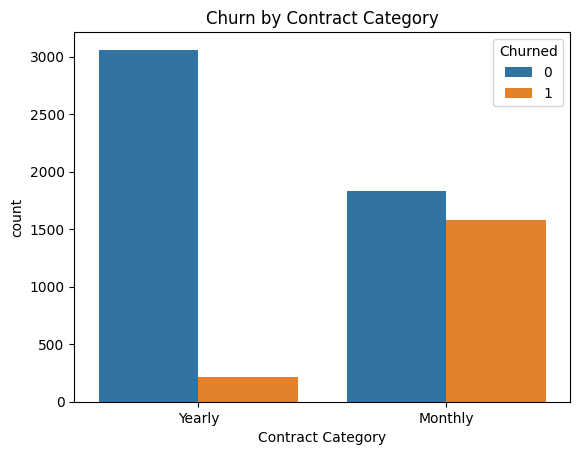

In [16]:
#Churn par Type de Contrat
import seaborn as sns

plt.figure()
sns.countplot(data=df, x="Contract Category", hue="Churned")
plt.title("Churn by Contract Category")
plt.show()

Les clients avec un contrat Month-to-Month présentent le churn le plus élevé.
Les contrats courts sont plus risqués et Les clients sans engagement long terme quittent plus facilement.
Les contrats annuels ou pluriannuels sont plus stables

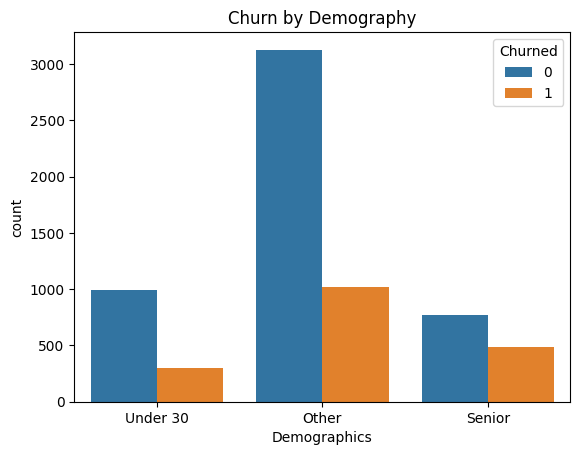

In [17]:
#Churn By Demography
plt.figure()
sns.countplot(data=df, x="Demographics", hue="Churned")
plt.title("Churn by Demography")
plt.show()

La catégorie “Other” présente le churn le plus élevé, suivie des Seniors
Les seniors peuvent être plus sensibles au service ou au prix

In [18]:
#Churn by State
df["State"].value_counts()
state_churn = df.groupby("State")["Churned"].mean().sort_values(ascending=False)
state_churn

,Churned
State,
CA,0.632353
OH,0.348101
PA,0.333333
MD,0.328571
NE,0.327869
NH,0.321429
MT,0.313869
OR,0.307692
KY,0.305085


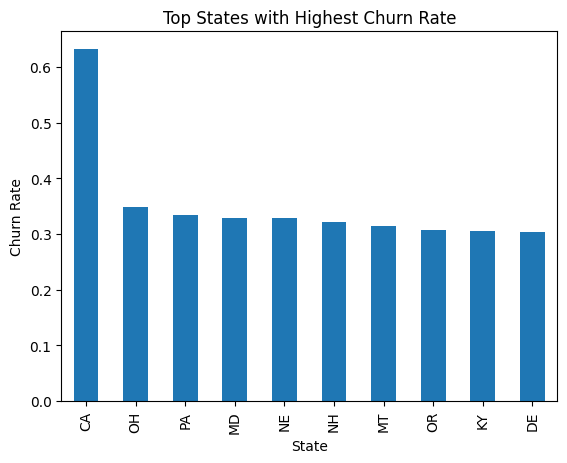

In [19]:
state_churn.head(10).plot(kind="bar")
plt.title("Top States with Highest Churn Rate")
plt.ylabel("Churn Rate")
plt.show()

CA: California presente le Taux le plus elevé
Certains états ont un churn significativement plus élevé
Cela peut être lié à : concurrence locale,prix,qualité du service,profil client régional

In [20]:
#Churn Reason
df["Churn Reason"].value_counts()
reason_counts = df["Churn Reason"].value_counts().head(10)
reason_counts

,count
Churn Reason,
Competitor made better offer,303
Competitor had better devices,297
Attitude of support person,203
Don't know,123
Competitor offered more data,110
Competitor offered higher download speeds,95
Attitude of service provider,84
Price too high,74
Product dissatisfaction,73


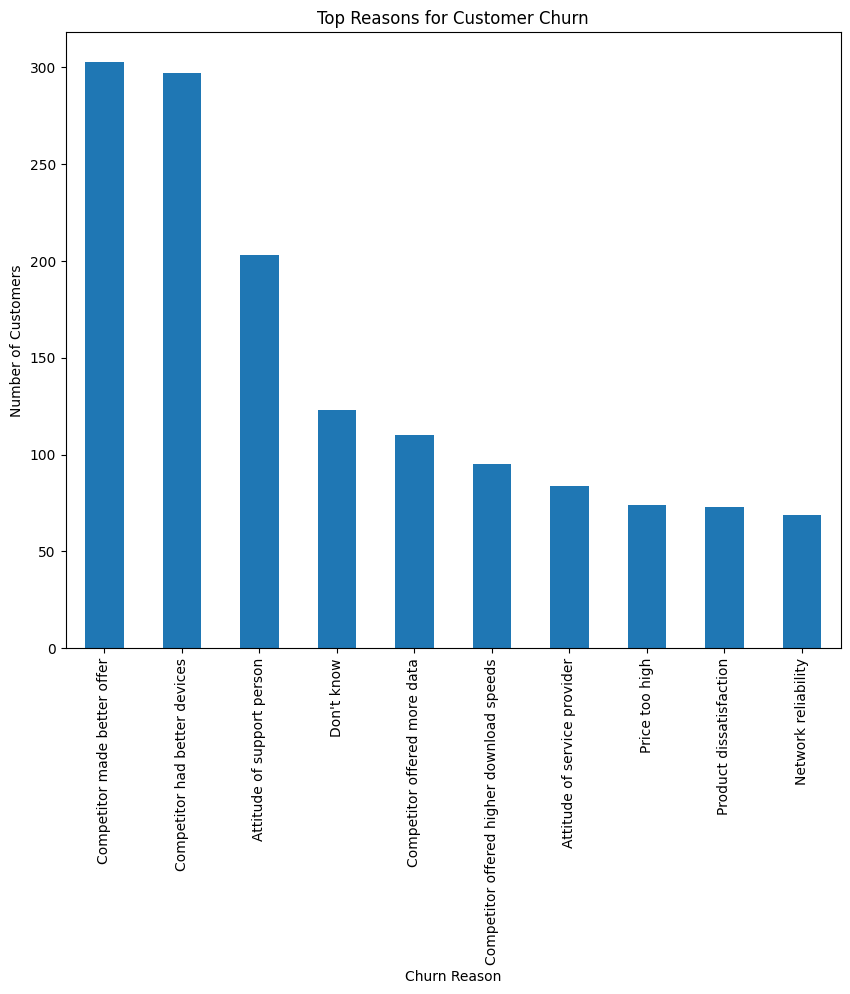

In [21]:
plt.figure(figsize=(10, 8))
reason_counts.plot(kind="bar")
plt.title("Top Reasons for Customer Churn")
plt.ylabel("Number of Customers")
plt.xticks(rotation=90)
plt.show()

les concurants qui proposent des forfaits et des appereilles plus formants sont la raison les plus fréquents de désabonnements

# ***Structure ML***

**Data Preparation for Machine Learning**

In [22]:
df_ml = df.copy()

In [23]:
target ="Churned"
cols_to_drop = [
    "Churn Reason",
    "Churn Category",
    "Customer Status",
    "Churn Label"
]
X=df_ml.drop(columns=[target])
X = X.drop(columns=cols_to_drop, errors="ignore")
Y= df_ml[target]

**Séparation de Donnée**

In [24]:
num_cols = X.select_dtypes(include=np.number).columns.tolist()
num_cols

['Account Length (in months)',
 'Local Calls',
 'Local Mins',
 'Intl Calls',
 'Intl Mins',
 'Extra International Charges',
 'Customer Service Calls',
 'Avg Monthly GB Download',
 'Extra Data Charges',
 'Age',
 'Number of Customers in Group',
 'Monthly Charge',
 'Total Charges',
 'Age (bins)']

In [25]:
cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()
cat_cols

['Intl Active',
 'Intl Plan',
 'Unlimited Data Plan',
 'State',
 'Gender',
 'Under 30',
 'Senior',
 'Group',
 'Device Protection & Online Backup',
 'Contract Type',
 'Payment Method',
 'Demographics',
 'Contract Category',
 'Grouped Consumption']

**Transformation des Colonnes**

In [26]:
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

In [27]:
categorical_pipe = Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("onehot",OneHotEncoder(handle_unknown= "ignore"))
])

In [28]:
preproces = ColumnTransformer(transformers=[
    ("num" , numeric_pipe , num_cols),
    ("cat" , categorical_pipe , cat_cols )

])

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

clf = Pipeline(steps=[
    ("preprocessing", preproces),
    ("model", RandomForestClassifier(random_state=42))
])

## **Entrainer RandomForest**

In [30]:
#Separation Train / Test
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)

In [31]:
clf.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Account Length (in months)',
                                                   'Local Calls', 'Local Mins',
                                                   'Intl Calls', 'Intl Mins',
                                                   'Extra International '
                                                   'Charges',
                                                   'Customer Service Calls',
                                                   'Avg Monthly GB Download',
                                                   'Extra Data Charges', 'Age',
                                                   'Number of Customers in '
                                                   'Group'...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Intl Active', 'Intl Plan',
                                                   'Unlimited Data Plan',
                                                   'State', 'Gender',
                                                   'Under 30', 'Senior',
                                                   'Group',
                                                   'Device Protection & Online '
                                                   'Backup',
                                                   'Contract Type',
                                                   'Payment Method',
                                                   'Demographics',
                                                   'Contract Category',
                                                   'Grouped Consumption'])])),
                ('model', RandomForestClassifier(random_state=42))])

In [32]:
y_pred = clf.predict(X_test)

In [33]:
y_proba = clf.predict_proba(X_test)[:, 1]

In [34]:
print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.905     0.945     0.925       979
           1      0.829     0.730     0.776       359

    accuracy                          0.887      1338
   macro avg      0.867     0.837     0.850      1338
weighted avg      0.885     0.887     0.885      1338



In [35]:
auc = roc_auc_score(y_test, y_proba)

In [36]:
print("ROC AUC:", round(auc, 3))

ROC AUC: 0.935



🔹 1. **Accuracy 👉 88.7%**

✔ Très bonne performance globale
✔ Modèle fiable pour classification générale

🔹 2. **Classe 1 (Churn) — le plus important**
Precision = 0.829
Recall = 0.730
F1-score = 0.776

💡 Interprétation : Le modèle détecte 73% des clients qui churnent ✅
Il fait peu d’erreurs quand il prédit churn (bonne précision)
Performance équilibrée 👍

🔹 3.** Classe 0 (Non churn)**
Recall = 0.945 → excellent
👉 Le modèle identifie très bien les clients fidèles

🔹 4.** ROC AUC 👉 0.935**

🔥 Très élevé → excellent pouvoir de discrimination
👉 le modèle distingue très bien churn vs non-churn

# **Conclusion **

Le taux de churn est de 26.86%, soit environ 1 client sur 4, ce qui représente un enjeu important pour l’entreprise.

L’analyse a montré que :
- Les contrats mensuels (Month-to-Month) présentent le plus fort risque de churn.
- Certains segments démographiques (Other et Seniors) sont plus exposés.
- Des variations existent selon les régions (ex : Californie).
- Les principales causes sont liées au prix, à la qualité du service et à la concurrence.

Le modèle Random Forest permet de prédire efficacement le churn (Accuracy : 88.7%, ROC AUC : 0.935) et d’identifier 73% des clients à risque.

👉 Ces résultats permettent de mettre en place des actions ciblées pour améliorer la fidélisation et réduire la perte de clients.